In [4]:
# Install SDV
!pip install -q sdv

# Imports
import pandas as pd

# Upload your dataset
from google.colab import files
uploaded = files.upload()

# Load dataset (replace filename if needed)
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving diabetes_dataset.csv to diabetes_dataset (1).csv


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [6]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframe(train_df)

In [9]:
for col in train_df.columns:
    if train_df[col].dtype == "object":
        metadata.update_column(col, sdtype="categorical")

In [11]:
from sdv.single_table import CTGANSynthesizer

model = CTGANSynthesizer(
    metadata,
    epochs=50
)

model.fit(train_df)

In [12]:
synthetic_df = model.sample(len(test_df))

synthetic_df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,40,Male,White,Highschool,Upper-Middle,Retired,Never,6,125,4.4,...,65,87,134,145,207,5.20,6.28,31.5,Type 2,1
1,45,Female,White,Postgraduate,Lower-Middle,Retired,Never,0,124,7.2,...,64,128,135,101,157,2.00,4.82,26.0,Type 2,1
2,62,Male,White,Graduate,Middle,Unemployed,Current,1,144,4.9,...,56,90,81,111,158,16.03,6.51,35.8,Pre-Diabetes,0
3,59,Male,Black,Graduate,Low,Employed,Never,2,64,7.2,...,57,136,100,101,164,19.31,6.04,21.5,Type 2,1
4,70,Female,White,Graduate,Lower-Middle,Employed,Never,2,126,6.1,...,60,117,177,123,164,11.87,7.14,49.4,Type 2,1


Text(0.5, 1.0, 'Synthetic Data')

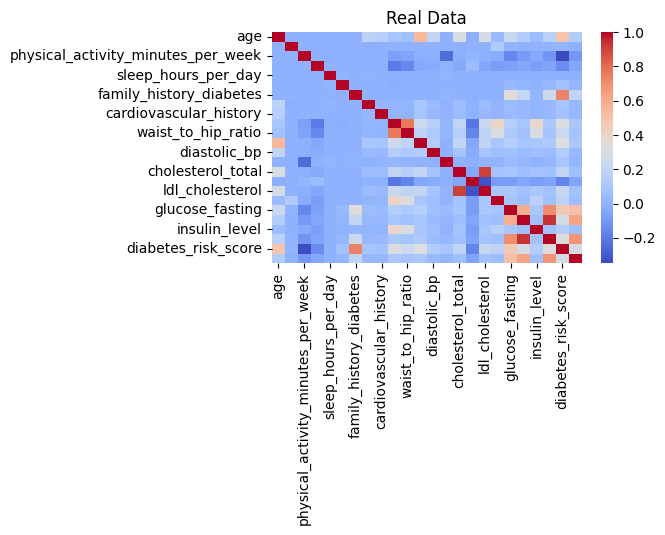

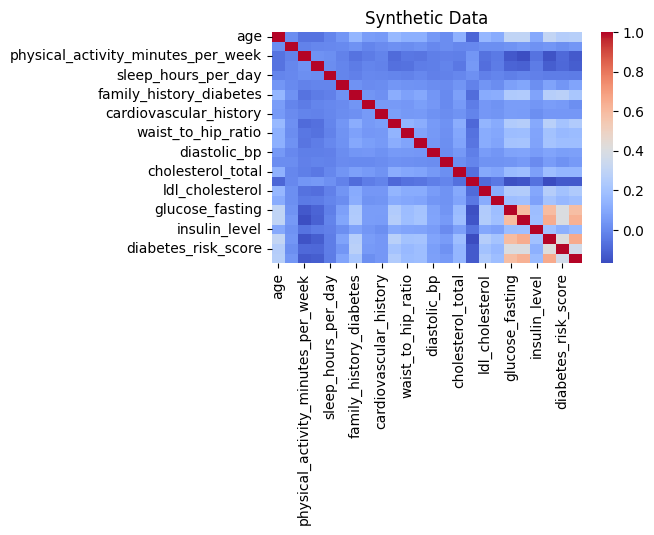

In [15]:
plt.figure(figsize=(5,3))
sns.heatmap(
    train_df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)
plt.title("Real Data")


plt.figure(figsize=(5,3))
sns.heatmap(
    synthetic_df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)
plt.title("Synthetic Data")

In [16]:
print(list(train_df.columns))
print(list(synthetic_df.columns))

['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes']
['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholest

In [17]:
real_corr = train_df.copy()
real_corr["diabetes_stage"] = real_corr["diabetes_stage"].astype("category").cat.codes

real_corr[["hba1c","diabetes_stage"]].corr()

,hba1c,diabetes_stage
hba1c,1.00000,0.71045
diabetes_stage,0.71045,1.00000


In [18]:
syn_corr = synthetic_df.copy()
syn_corr["diabetes_stage"] = syn_corr["diabetes_stage"].astype("category").cat.codes

syn_corr[["hba1c","diabetes_stage"]].corr()

,hba1c,diabetes_stage
hba1c,1.000000,0.639479
diabetes_stage,0.639479,1.000000


In [19]:
from sdv.evaluation.single_table import evaluate_quality

quality = evaluate_quality(
    real_data=test_df,
    synthetic_data=synthetic_df,
    metadata=metadata
)

quality

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 34.41it/s]|
Column Shapes Score: 91.59%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:04<00:00, 107.07it/s]|
Column Pair Trends Score: 80.97%

Overall Score (Average): 86.28%



In [20]:
combined = pd.concat([test_df, synthetic_df])
combined = pd.get_dummies(combined)

real = combined.iloc[:len(test_df)]
synth = combined.iloc[len(test_df):]

In [21]:
X_real = real.drop("diagnosed_diabetes", axis=1)
y_real = real["diagnosed_diabetes"]

X_synth = synth.drop("diagnosed_diabetes", axis=1)
y_synth = synth["diagnosed_diabetes"]

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_synth, y_synth)

accuracy = rf.score(X_real, y_real)

print("Accuracy:", accuracy)

Accuracy: 0.976


In [24]:
drop_cols = [
    "diagnosed_diabetes",
    "diabetes_stage",
    "diabetes_risk_score",
    "hba1c",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level"
]

X_real = real.drop(drop_cols, axis=1, errors="ignore")
y_real = real["diagnosed_diabetes"]

X_synth = synth.drop(drop_cols, axis=1, errors="ignore")
y_synth = synth["diagnosed_diabetes"]

In [25]:
rf.fit(X_synth, y_synth)
print(rf.score(X_real, y_real))

0.99745


In [26]:
import pandas as pd

imp = pd.Series(
    rf.feature_importances_,
    index=X_real.columns
).sort_values(ascending=False)

print(imp.head(10))

diabetes_stage_Type 2          0.282856
diabetes_stage_Pre-Diabetes    0.169878
diabetes_stage_No Diabetes     0.061875
bmi                            0.041252
ldl_cholesterol                0.039199
age                            0.032763
waist_to_hip_ratio             0.031940
cholesterol_total              0.030532
triglycerides                  0.028562
systolic_bp                    0.025832
dtype: float64


In [27]:
drop_cols = [col for col in real.columns if "diabetes_stage" in col]

X_real = real.drop(drop_cols + ["diagnosed_diabetes"], axis=1)
y_real = real["diagnosed_diabetes"]

X_synth = synth.drop(drop_cols + ["diagnosed_diabetes"], axis=1)
y_synth = synth["diagnosed_diabetes"]

In [28]:
rf.fit(X_synth, y_synth)
print(rf.score(X_real, y_real))

0.85185


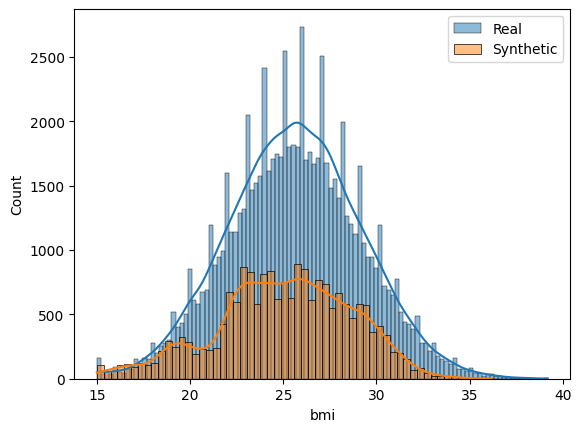

In [29]:
sns.histplot(train_df["bmi"], label="Real", kde=True)
sns.histplot(synthetic_df["bmi"], label="Synthetic", kde=True)
plt.legend()

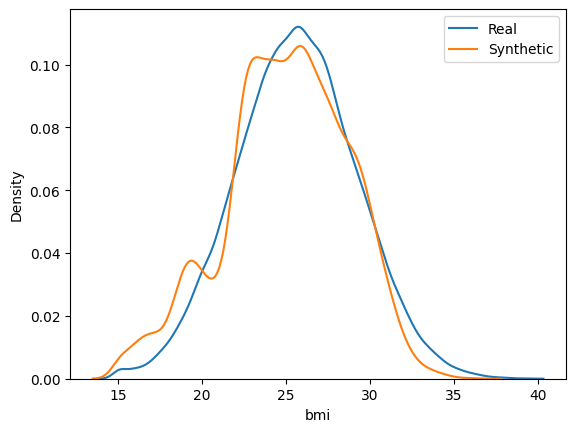

In [31]:
sns.kdeplot(train_df["bmi"], label="Real")
sns.kdeplot(synthetic_df["bmi"], label="Synthetic")
plt.legend()

In [32]:
from sdv.evaluation.single_table import evaluate_quality

quality = evaluate_quality(
    real_data=test_df,
    synthetic_data=synthetic_df,
    metadata=metadata
)

quality

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 31/31 [00:00<00:00, 48.93it/s]|
Column Shapes Score: 91.59%

(2/2) Evaluating Column Pair Trends: |██████████| 465/465 [00:06<00:00, 68.32it/s]| 
Column Pair Trends Score: 80.97%

Overall Score (Average): 86.28%



In [33]:
model.save("ctgan_healthcare.pkl")